In [1]:
import os
import glob
import numpy as np
import xarray as xr
import pandas as pd
import cartopy.crs as ccrs
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import matplotlib.path as mpath
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import geocat.viz as gv

/glade/work/turuncu/ML/envs/aurora/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
regions = {
    "Global": {"lat_min": -90, "lat_max": 90, "lon_min": 0, "lon_max": 360},
    "Global Land": {"lat_min": -90, "lat_max": 90, "lon_min": 0, "lon_max": 360, "over_land": True},
    "Global Ocean": {"lat_min": -90, "lat_max": 90, "lon_min": 0, "lon_max": 360, "over_ocean": True},
    "Europe": {"lat_min": 35, "lat_max": 70, "lon_min": -10, "lon_max": 40, "over_land": True}, # 35N-70N, 10W-40E
    "North America": {"lat_min": 15, "lat_max": 70, "lon_min": 198, "lon_max": 309, "over_land": True}, # 15N-75N, 140W-50W
    "South America": {"lat_min": -60, "lat_max": 15, "lon_min": 280, "lon_max": 330, "over_land": True}, # 60S-15N, 80W-30W
    "Africa": {"lat_min": -35, "lat_max": 35, "lon_min": -20, "lon_max": 55, "over_land": True}, # 35S-35N, 20W-55E
    "Asia": {"lat_min": 30, "lat_max": 75, "lon_min": 55, "lon_max": 190, "over_land": True}, # 5N-55N, 55E-180E
    "Australia": {"lat_min": -45, "lat_max": -10, "lon_min": 110, "lon_max": 155, "over_land": True}, # 45S-10S, 110E-155E
    "Tropics": {"lat_min": -20, "lat_max": 20, "lon_min": 0, "lon_max": 360}, # 20S-20N, global
    "Nino 1+2": {"lat_min": -10, "lat_max": 0, "lon_min":270 , "lon_max": 280, "over_ocean": True}, # 10S-0N, 90W-80W
    "Nino 3": {"lat_min": -5, "lat_max": 5, "lon_min": 210, "lon_max": 270, "over_ocean": True}, # 5N-5S, 150W-90W
    "Nino 3.4": {"lat_min": -5, "lat_max": 5, "lon_min": 190, "lon_max": 240, "over_ocean": True}, # 5N-5S, 170W-120W
    "Nino 4": {"lat_min": -5, "lat_max": 5, "lon_min": 160, "lon_max": 210, "over_ocean": True}, # 5N-5S, 160E-150W
    "Gulf of Mexico": {"lat_min": 18, "lat_max": 30, "lon_min": 263, "lon_max": 278, "over_ocean": True}, # 18N-30N, 97W-82W
    "North Atlantic Ocean": {"lat_min": 0, "lat_max": 60, "lon_min": 280, "lon_max": 360, "over_ocean": True}, # 0N-60N, 80W-0E
    "Indian Ocean": {"lat_min": -40, "lat_max": 30, "lon_min": 20, "lon_max": 120, "over_ocean": True}, # 40S-30N, 20E-120E
    "Western Pacific Ocean": {"lat_min": -10, "lat_max": 30, "lon_min": 120, "lon_max": 160, "over_ocean": True}, # 10S-30N, 120E-160E
    "Eastern Pacific Ocean": {"lat_min": -10, "lat_max": 30, "lon_min": 240, "lon_max": 280, "over_ocean": True}, # 10S-30N, 120W-80W
    "Southern Ocean": {"lat_min": -90, "lat_max": -60, "lon_min": 0, "lon_max": 360, "over_ocean": True}, # 90S-60S, global
    "Arctic Ocean": {"lat_min": 60, "lat_max": 90, "lon_min": 0, "lon_max": 360, "over_ocean": True}, # 60N-90N, global
    "Antarctic Ocean": {"lat_min": -90, "lat_max": -50, "lon_min": 0, "lon_max": 360, "over_ocean": True}, # 50S-90S, global
}

In [3]:
# from https://github.com/google-research/weatherbench2/blob/021c0b33d9dd165d1e7aa476fcc985be855fbc7b/weatherbench2/metrics.py#L40
def _latitude_cell_bounds(x: np.ndarray) -> np.ndarray:
  pi_over_2 = np.array([np.pi / 2], dtype=x.dtype)
  return np.concatenate([-pi_over_2, (x[:-1] + x[1:]) / 2, pi_over_2])
    
# From https://github.com/google-research/weatherbench2/blob/021c0b33d9dd165d1e7aa476fcc985be855fbc7b/weatherbench2/metrics.py#L45
def _cell_area_from_latitude(points: np.ndarray) -> np.ndarray:
  """Calculate the area overlap as a function of latitude."""
  bounds = _latitude_cell_bounds(points)
  upper = bounds[1:]
  lower = bounds[:-1]
  # normalized cell area: integral from lower to upper of cos(latitude)
  return np.sin(upper) - np.sin(lower)

# From https://github.com/google-research/weatherbench2/blob/021c0b33d9dd165d1e7aa476fcc985be855fbc7b/weatherbench2/metrics.py#L55
def get_lat_weights(ds: xr.Dataset) -> xr.DataArray:
  """Computes latitude/area weights from latitude coordinate of dataset."""
  weights = _cell_area_from_latitude(np.deg2rad(ds.latitude.data))
  weights /= np.mean(weights)
  weights = ds.latitude.copy(data=weights)
  return weights

In [ ]:
# Load datasets
month = "01"

# original run, 2 rollout, +6h and +12h with all ERA5
ds_old = xr.open_dataset(f'/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/2021{month}01_aurora/pred_merged_35d.nc')
ds_old = ds_old.reindex(latitude=ds_old.latitude[::-1])
# true prediction, 1 rollout, +6h with all Prediction except at the begining using ERA5
ds_new = xr.open_dataset(f'/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/2021{month}01_aurora_r2/pred_merged_35d.nc')
ds_new = ds_new.reindex(latitude=ds_new.latitude[::-1])
# semi-true prediction, 1 rollout, +6h with all Prediction except at the begining using ERA5 and SST from ERA5 at every step
ds_new_2 = xr.open_dataset(f'/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/2021{month}01_aurora_r3/pred_merged_35d.nc')
ds_new_2 = ds_new_2.reindex(latitude=ds_new_2.latitude[::-1])
# true prediction, 1 rollout, +6h with all Prediction except at the begining using ERA5 and also getting SST from MOM6
ds_new_3 = xr.open_dataset(f'/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/2021{month}01_aurora_two_way_r4/pred_merged_35d.nc')
ds_new_3 = ds_new_3.reindex(latitude=ds_new_3.latitude[::-1])

# Calculate weights
weights = get_lat_weights(ds_old)
weights2d = xr.DataArray(np.tile(weights.values[:,np.newaxis], (1, ds_old.longitude.size)))
ds_old["weights"] = (("latitude", "longitude"), weights2d.data)

# Variables
vars = {
    "10u"  : "m/s",
    "10v"  : "m/s",
    "msl"  : "hPa",
    "2t"   : "K",
    "2q"   : "g/kg",
    "lwdn" : "W/m2",
    "swdn" : "W/m2",
    "sst"  : "K"
}

In [ ]:
# Point, Boulder, CO
lat = 40.0190
lon = 105.2747

# Get region extent
reg = "Nino 3.4"
lat_min = regions[reg]['lat_min']
lat_max = regions[reg]['lat_max']
lon_min = regions[reg]['lon_min']
lon_max = regions[reg]['lon_max']

# Create plot
fig, axs = plt.subplots(4, 2, figsize=(12, 12), layout='constrained')
ax = axs.flat

# Plot
indx = 0
for v, units in vars.items():
    # Get data for x axis
    x = ds_old.coords['time']#.values
    x_h = (x - x[0])/21600000000000
    x_h = x_h.astype(int)
    x_day = (x - x[0])/86400000000000
    x_day = x_day.astype(int)
    
    #data_old = ds_old[v].sel(latitude=lat, longitude=lon, method='nearest')
    ds_old_subset = ds_old.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
    lsm = ds_old_subset.slt.isel(time=0) == 0
    data_old = ds_old_subset[v].where(lsm).weighted(ds_old_subset.weights).mean(dim=["longitude", "latitude"])
    if v == 'msl':
        data_old = data_old/100.0
    if v == '2q':
        data_old = data_old*100.0
    ax[indx].plot(x_h, data_old, color='red', label="PRED1")

    #data_new = ds_new[v].sel(latitude=lat, longitude=lon, method='nearest')
    ds_new_subset = ds_new.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
    data_new = ds_new_subset[v].where(lsm).weighted(ds_old_subset.weights).mean(dim=["longitude", "latitude"])
    if v == 'msl':
        data_new = data_new/100.0
    if v == '2q':
        data_new = data_new*100.0
    ax[indx].plot(x_h, data_new, color='blue', label="PRED2")

    #data_new_2 = ds_new_2[v].sel(latitude=lat, longitude=lon, method='nearest')
    ds_new_subset_2 = ds_new_2.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
    data_new_2 = ds_new_subset_2[v].where(lsm).weighted(ds_old_subset.weights).mean(dim=["longitude", "latitude"])
    if v == 'msl':
        data_new_2 = data_new_2/100.0
    if v == '2q':
        data_new_2 = data_new_2*100.0
    ax[indx].plot(x_h, data_new_2, color='green', label="PRED3")

    #data_new_3 = ds_new_3[v].sel(latitude=lat, longitude=lon, method='nearest')
    ds_new_subset_3 = ds_new_3.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
    data_new_3 = ds_new_subset_3[v].where(lsm).weighted(ds_old_subset.weights).mean(dim=["longitude", "latitude"])
    if v == 'msl':
        data_new_3 = data_new_3/100.0
    if v == '2q':
        data_new_3 = data_new_3*100.0
    ax[indx].plot(x_h, data_new_3, color='black', label="PRED4")
    
    if indx == 0:
        ax[indx].legend(ncol=1, loc='lower left', fontsize=10)
    ax[indx].text(-0.05, 0.5, f"{v} [{units}]", transform=ax[indx].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)
    indx=indx+1

In [ ]:
data_path = "/glade/derecho/scratch/turuncu/data/Run_global/postprocessed"

months = {
    "JAN": 1,
    "APR": 4,
    "JUL": 7,
    "OCT": 10
}

fig, ax = plt.subplots(4, 4, figsize=(12, 6), layout='constrained', subplot_kw={'projection': ccrs.Robinson()})

irow = 0
for label, val in months.items():
    # Load datasets
    ds_aur1_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora/ocn_merged_35d_remap_bil_tmean.nc"))
    ds_aur2_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_r2/ocn_merged_35d_remap_bil_tmean.nc"))
    ds_aur3_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_r3/ocn_merged_35d_remap_bil_tmean.nc"))
    ds_aur4_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_two_way_r4/ocn_merged_35d_remap_bil_tmean.nc"))

    # REF - forced with ERA5
    data_aur1 = ds_aur1_mean.SST.isel(time=0)
    im0 = data_aur1.plot(ax=ax[irow,0], transform=ccrs.PlateCarree(), vmin=-2, vmax=28, cmap='inferno', add_colorbar=False)
    ax[irow,0].coastlines(linewidth=0.5)
    fig.colorbar(im0, ax=ax[irow,0], pad=0.08, aspect=20, shrink=0.9, label='SST [degC]')

    # FREE - autoregressive rollout
    data_aur2 = ds_aur2_mean.SST.isel(time=0)
    data_aur2 = data_aur2-data_aur1
    im1 = data_aur2.plot(ax=ax[irow,1], transform=ccrs.PlateCarree(), vmin=-1, vmax=1, cmap='RdBu_r', add_colorbar=False)
    ax[irow,1].coastlines(linewidth=0.5)

    # FREE - autoregressive rollout SST is replaced with ERA5
    data_aur3 = ds_aur3_mean.SST.isel(time=0)
    data_aur3 = data_aur3-data_aur1
    im2 = data_aur3.plot(ax=ax[irow,2], transform=ccrs.PlateCarree(), vmin=-1, vmax=1, cmap='RdBu_r', add_colorbar=False)
    ax[irow,2].coastlines(linewidth=0.5)

    # FREE - autoregressive rollout SST is replaced with MOM6 SST
    data_aur4 = ds_aur4_mean.SST.isel(time=0)
    data_aur4 = data_aur4-data_aur1
    im3 = data_aur4.plot(ax=ax[irow,3], transform=ccrs.PlateCarree(), vmin=-1, vmax=1, cmap='RdBu_r', add_colorbar=False)
    ax[irow,3].coastlines(linewidth=0.5)
    fig.colorbar(im1, ax=ax[irow,3], pad=0.08, aspect=20, shrink=0.9, label=r'$\Delta SST$ [degC]')

    # Labels
    if irow == 0:
        ax[irow,0].set_title("REF", fontweight='bold', fontsize=10)
        ax[irow,1].set_title("FREE-REF", fontweight='bold', fontsize=10)
        ax[irow,2].set_title("FREE[ERA5]-REF", fontweight='bold', fontsize=10)
        ax[irow,3].set_title("FREE[MOM6]-REF", fontweight='bold', fontsize=10)
    else:
        ax[irow,0].set_title("")
        ax[irow,1].set_title("")
        ax[irow,2].set_title("")
        ax[irow,3].set_title("")

    ax[irow,0].text(-0.1, 0.5, f"{label}", transform=ax[irow,0].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

    irow = irow+1

# Save to file
#filename = "diff_aur2-aur1_sst.png"
#plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)

In [ ]:
data_path = "/glade/derecho/scratch/turuncu/data/Run_global/postprocessed"

months = {
    "JAN": 1,
    "APR": 4,
    "JUL": 7,
    "OCT": 10
}

fig, ax = plt.subplots(4, 4, figsize=(12, 6), layout='constrained', subplot_kw={'projection': ccrs.Robinson()})

var = "2t"

irow = 0
for label, val in months.items():
    # Load datasets
    ds_aur1_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora/pred_merged_35d_remap_bil_tmean.nc"))
    ds_aur2_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_r2/pred_merged_35d_remap_bil_tmean.nc"))
    ds_aur3_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_r3/pred_merged_35d_remap_bil_tmean.nc"))
    ds_aur4_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_two_way_r4/pred_merged_35d_remap_bil_tmean.nc"))

    # REF - forced with ERA5
    data_aur1 = ds_aur1_mean[var].isel(time=0)-273.15
    im0 = data_aur1.plot(ax=ax[irow,0], transform=ccrs.PlateCarree(), vmin=-28, vmax=28, cmap='inferno', add_colorbar=False)
    ax[irow,0].coastlines(linewidth=0.5)
    fig.colorbar(im0, ax=ax[irow,0], pad=0.08, aspect=20, shrink=0.9, label='2T [degC]')

    # FREE - autoregressive rollout
    data_aur2 = ds_aur2_mean[var].isel(time=0)-273.15
    data_aur2 = data_aur2-data_aur1
    im1 = data_aur2.plot(ax=ax[irow,1], transform=ccrs.PlateCarree(), vmin=-4, vmax=4, cmap='RdBu_r', add_colorbar=False)
    ax[irow,1].coastlines(linewidth=0.5)

    # FREE - autoregressive rollout SST is replaced with ERA5
    data_aur3 = ds_aur3_mean[var].isel(time=0)-273.15
    data_aur3 = data_aur3-data_aur1
    im2 = data_aur3.plot(ax=ax[irow,2], transform=ccrs.PlateCarree(), vmin=-4, vmax=4, cmap='RdBu_r', add_colorbar=False)
    ax[irow,2].coastlines(linewidth=0.5)

    # FREE - autoregressive rollout SST is replaced with MOM6 SST
    data_aur4 = ds_aur4_mean[var].isel(time=0)-273.15
    data_aur4 = data_aur4-data_aur1
    im3 = data_aur4.plot(ax=ax[irow,3], transform=ccrs.PlateCarree(), vmin=-4, vmax=4, cmap='RdBu_r', add_colorbar=False)
    ax[irow,3].coastlines(linewidth=0.5)
    fig.colorbar(im1, ax=ax[irow,3], pad=0.08, aspect=20, shrink=0.9, label=r'$\Delta 2T$ [degC]')

    # Labels
    if irow == 0:
        ax[irow,0].set_title("AUR_F", fontweight='bold', fontsize=10)
        ax[irow,1].set_title("AUR_R-AUR_F", fontweight='bold', fontsize=10)
        ax[irow,2].set_title("AUR_RE-AUR_F", fontweight='bold', fontsize=10)
        ax[irow,3].set_title("AUR_RM-AUR_F", fontweight='bold', fontsize=10)
    else:
        ax[irow,0].set_title("")
        ax[irow,1].set_title("")
        ax[irow,2].set_title("")
        ax[irow,3].set_title("")

    ax[irow,0].text(-0.1, 0.5, f"{label}", transform=ax[irow,0].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

    irow = irow+1

# Save to file
filename = "Fig_2t_spatial.png"
plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)

In [ ]:
data_path = "/glade/derecho/scratch/turuncu/data/Run_global/postprocessed"

months = {
    "JAN": 1,
    "APR": 4,
    "JUL": 7,
    "OCT": 10
}

fig, ax = plt.subplots(4, 4, figsize=(12, 6), layout='constrained', subplot_kw={'projection': ccrs.Robinson()})

#var = "z"
var = "t"

irow = 0
for label, val in months.items():
    # Load datasets
    ds_aur1_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora/pred_merged_35d_remap_bil_tmean.nc"))
    ds_aur2_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_r2/pred_merged_35d_remap_bil_tmean.nc"))
    ds_aur3_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_r3/pred_merged_35d_remap_bil_tmean.nc"))
    ds_aur4_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_two_way_r4/pred_merged_35d_remap_bil_tmean.nc"))

    # REF - forced with ERA5
    data_aur1 = ds_aur1_mean[var].sel(level=500).isel(time=0)/9.81
    im0 = data_aur1.plot(ax=ax[irow,0], transform=ccrs.PlateCarree(), vmin=4750, vmax=6000, cmap='inferno', add_colorbar=False)
    ax[irow,0].coastlines(linewidth=0.5)
    fig.colorbar(im0, ax=ax[irow,0], pad=0.08, aspect=20, shrink=0.9, label='Z [m]')

    # FREE - autoregressive rollout
    data_aur2 = ds_aur2_mean[var].sel(level=500).isel(time=0)/9.81
    data_aur2 = data_aur2-data_aur1
    im1 = data_aur2.plot(ax=ax[irow,1], transform=ccrs.PlateCarree(), vmin=-100, vmax=100, cmap='RdBu_r', add_colorbar=False)
    ax[irow,1].coastlines(linewidth=0.5)

    # FREE - autoregressive rollout SST is replaced with ERA5
    data_aur3 = ds_aur3_mean[var].sel(level=500).isel(time=0)/9.81
    data_aur3 = data_aur3-data_aur1
    im2 = data_aur3.plot(ax=ax[irow,2], transform=ccrs.PlateCarree(), vmin=-100, vmax=100, cmap='RdBu_r', add_colorbar=False)
    ax[irow,2].coastlines(linewidth=0.5)

    # FREE - autoregressive rollout SST is replaced with MOM6 SST
    data_aur4 = ds_aur4_mean[var].sel(level=500).isel(time=0)/9.81
    data_aur4 = data_aur4-data_aur1
    im3 = data_aur4.plot(ax=ax[irow,3], transform=ccrs.PlateCarree(), vmin=-100, vmax=100, cmap='RdBu_r', add_colorbar=False)
    ax[irow,3].coastlines(linewidth=0.5)
    fig.colorbar(im1, ax=ax[irow,3], pad=0.08, aspect=20, shrink=0.9, label=r'$\Delta Z$ [m]')

    # Labels
    if irow == 0:
        ax[irow,0].set_title("AUR_F", fontweight='bold', fontsize=10)
        ax[irow,1].set_title("AUR_R-AUR_F", fontweight='bold', fontsize=10)
        ax[irow,2].set_title("AUR_RE-AUR_F", fontweight='bold', fontsize=10)
        ax[irow,3].set_title("AUR_RM-AUR_F", fontweight='bold', fontsize=10)
    else:
        ax[irow,0].set_title("")
        ax[irow,1].set_title("")
        ax[irow,2].set_title("")
        ax[irow,3].set_title("")

    ax[irow,0].text(-0.1, 0.5, f"{label}", transform=ax[irow,0].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

    irow = irow+1

# Save to file
#filename = "diff_aur2-aur1_sst.png"
#plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)

In [ ]:
data_path = "/glade/derecho/scratch/turuncu/data/Run_global/postprocessed"
region_list = ["Global Ocean"
               'Arctic Ocean',
               "Southern Ocean",
               'North Atlantic Ocean',
               "Eastern Pacific Ocean",
               "Western Pacific Ocean",
               "Indian Ocean",
               "Nino 1+2",
               "Nino 3",
               "Nino 3.4",
               "Nino 4",
               "Gulf of Mexico",
               "Tropics",
               "Global",
               "Global Land",
               "Europe",
               "North America",
               "South America",
               "Africa",
               "Asia",
               "Australia"
              ]
region_list = [
    'Global Ocean',
    'Arctic Ocean',
    'Eastern Pacific Ocean',
    'Indian Ocean',
    'North Atlantic Ocean',
    'Southern Ocean',
    'Western Pacific Ocean',
    'Nino 1+2',
    'Nino 3',
    'Nino 3.4',
    'Nino 4',
    'Gulf of Mexico',
    'Africa',
    'Asia',
    'Australia',
    'Europe',
    'Global',
    'Global Land',
    'North America',
    'South America',
    'Tropics']
ds_aur1 = xr.open_dataset(f'/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/20210101_aurora_r2/stats/stat_surface.nc')
ds_aur1 = ds_aur1.sel(region=region_list)
print(ds_aur1.region.values)

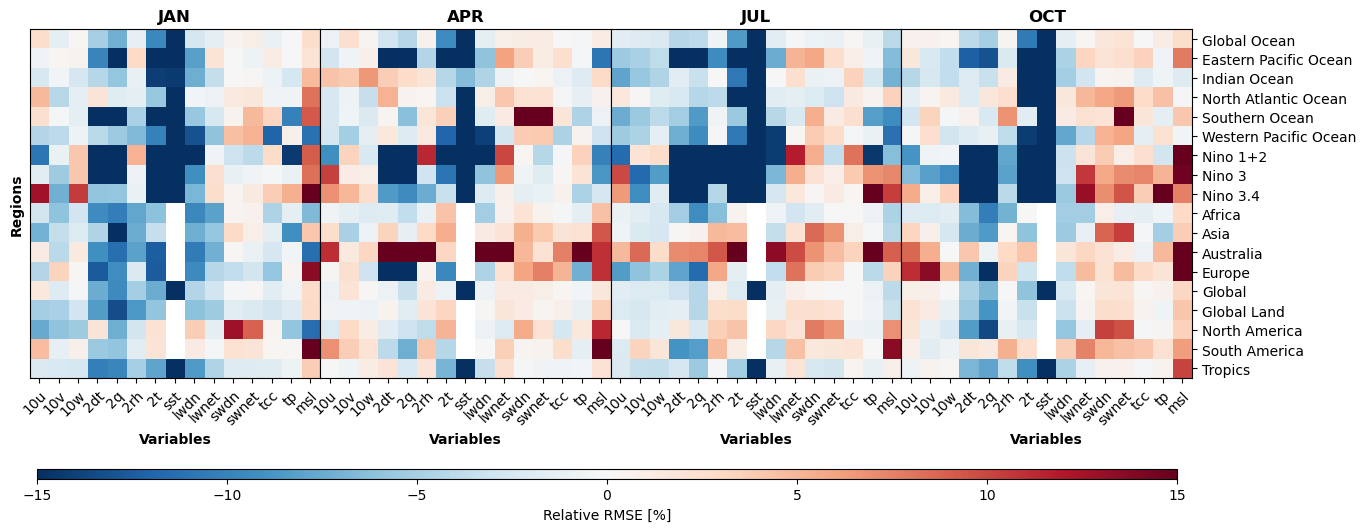

In [13]:
data_path = "/glade/derecho/scratch/turuncu/data/Run_global/postprocessed"

months = {
    "JAN": 1,
    "APR": 4,
    "JUL": 7,
    "OCT": 10
}

region_list = [
    'Global Ocean',
    #'Arctic Ocean',
    'Eastern Pacific Ocean',
    'Indian Ocean',
    'North Atlantic Ocean',
    'Southern Ocean',
    'Western Pacific Ocean',
    'Nino 1+2',
    'Nino 3',
    'Nino 3.4',
    #'Nino 4',
    #'Gulf of Mexico',
    'Africa',
    'Asia',
    'Australia',
    'Europe',
    'Global',
    'Global Land',
    'North America',
    'South America',
    'Tropics']

var_list = ['10u', '10v', '10w', '2dt', '2q', '2rh', '2t', 'sst', 'lwdn', 'lwnet', 'swdn', 'swnet', 'tcc', 'tp', 'msl']

fig, axs = plt.subplots(1, 4, figsize=(15,10), gridspec_kw={'wspace': 0.0, 'hspace': 0.0})
ax = axs.flat

indx = 0
for label, val in months.items():
    # true prediction, 1 rollout, +6h with all Prediction except at the begining using ERA5
    ds_aur1 = xr.open_dataset(f'/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/2021{val:02}01_aurora_r2/stats/stat_surface.nc')
    ds_aur1 = ds_aur1.sel(region=region_list, variable=var_list)
    #ds_aur1 = ds_aur1.sel(variable=['10u', '10v', '10w', '2t', 'msl', 'sst', 'tcc', 'tp'])
    # semi-true prediction, 1 rollout, +6h with all Prediction except at the begining using ERA5 and SST from ERA5 at every step
    ds_aur2 = xr.open_dataset(f'/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/2021{val:02}01_aurora_two_way_r4/stats/stat_surface.nc')
    ds_aur2 = ds_aur2.sel(region=region_list, variable=var_list)
    #ds_aur2 = ds_aur2.sel(variable=['10u', '10v', '10w', '2t', 'msl', 'sst', 'tcc', 'tp'])

    # Set list of regions and simulations
    regions = ds_aur1.region.values
    variable = ds_aur1.variable.values
    
    # Get data
    data1 = ds_aur1['rmse_wgt_mean'].isel(rollout_step=0)
    data2 = ds_aur2['rmse_wgt_mean'].isel(rollout_step=0)
    data1_relative = (data2-data1)/data1*100.0
    data1_relative = data1_relative.mean(['time'])

    im1 = ax[indx].imshow(data1_relative, cmap="RdBu_r", vmin=-15, vmax=15)
    ax[indx].set_xticklabels([])
    ax[indx].set_xlabel('')
    ax[indx].yaxis.tick_right()
    ax[indx].tick_params(axis='y', labelright=True, labelleft=False)
    ax[indx].set_yticks(range(len(regions)), labels=regions, fontsize=10)
    ax[indx].set_xticks(range(len(variable)), labels=variable, rotation=45, ha="right", rotation_mode="anchor")
    ax[indx].set_xlabel('Variables', fontsize=10, fontweight='bold')
    if indx == 0:
        ax[indx].set_ylabel('Regions', fontsize=10, fontweight='bold')

    # Add title
    ax[indx].set_title(label, fontsize=12, fontweight='bold')

    indx=indx+1

cbar_ax = fig.add_axes([0.13, 0.22, 0.76, 0.01])
fig.colorbar(ax[0].images[0], cax=cbar_ax, orientation='horizontal', label='Relative RMSE [%]')
fig.savefig(f"Fig_relative_RMSE.png", dpi=300, bbox_inches='tight')

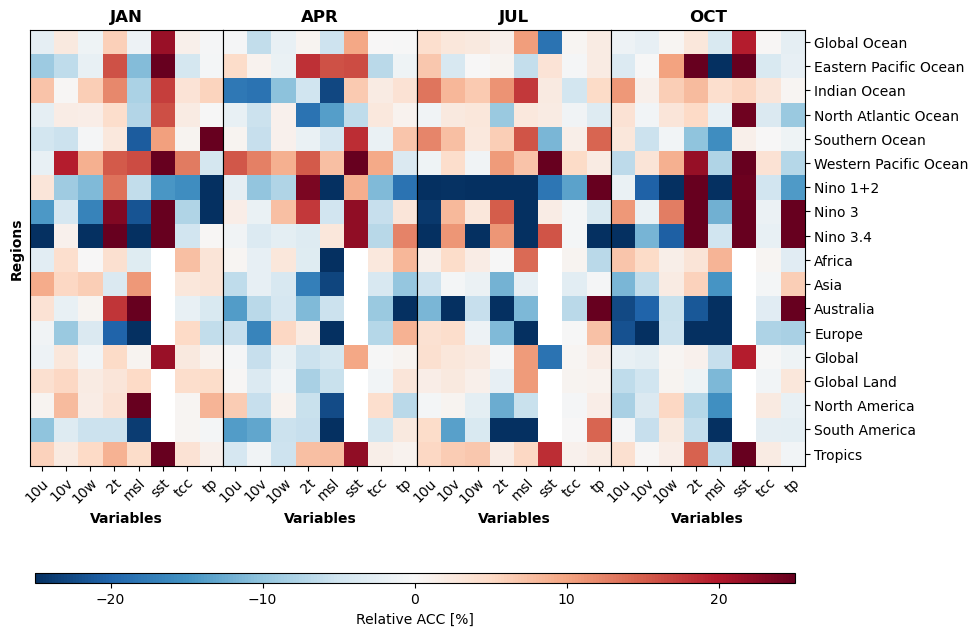

In [4]:
data_path = "/glade/derecho/scratch/turuncu/data/Run_global/postprocessed"

months = {
    "JAN": 1,
    "APR": 4,
    "JUL": 7,
    "OCT": 10
}

region_list = [
    'Global Ocean',
    #'Arctic Ocean',
    'Eastern Pacific Ocean',
    'Indian Ocean',
    'North Atlantic Ocean',
    'Southern Ocean',
    'Western Pacific Ocean',
    'Nino 1+2',
    'Nino 3',
    'Nino 3.4',
    #'Nino 4',
    #'Gulf of Mexico',
    'Africa',
    'Asia',
    'Australia',
    'Europe',
    'Global',
    'Global Land',
    'North America',
    'South America',
    'Tropics']

var_list=['10u', '10v', '10w', '2t', 'msl', 'sst', 'tcc', 'tp']

fig, axs = plt.subplots(1, 4, figsize=(10,10), gridspec_kw={'wspace': 0.0, 'hspace': 0.0})
ax = axs.flat

indx = 0
for label, val in months.items():
    # true prediction, 1 rollout, +6h with all Prediction except at the begining using ERA5
    ds_aur1 = xr.open_dataset(f'/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/2021{val:02}01_aurora_r2/stats/stat_surface.nc')
    ds_aur1 = ds_aur1.sel(region=region_list, variable=var_list)
    # semi-true prediction, 1 rollout, +6h with all Prediction except at the begining using ERA5 and SST from ERA5 at every step
    ds_aur2 = xr.open_dataset(f'/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/2021{val:02}01_aurora_two_way_r4/stats/stat_surface.nc')
    ds_aur2 = ds_aur2.sel(region=region_list, variable=var_list)

    # Set list of regions and simulations
    regions = ds_aur1.region.values
    variable = ds_aur1.variable.values

    # Get data
    data1 = ds_aur1['acc_lat_mean'].isel(rollout_step=0)
    data2 = ds_aur2['acc_lat_mean'].isel(rollout_step=0)
    data1_relative = (data2-data1)/(1-data1)*100.0
    data1_relative = data1_relative.mean(['time'])
    
    im1 = ax[indx].imshow(data1_relative, cmap="RdBu_r", vmin=-25, vmax=25)
    ax[indx].set_xticklabels([])
    ax[indx].set_xlabel('')
    ax[indx].yaxis.tick_right()
    ax[indx].tick_params(axis='y', labelright=True, labelleft=False)
    ax[indx].set_yticks(range(len(regions)), labels=regions, fontsize=10)
    ax[indx].set_xticks(range(len(variable)), labels=variable, rotation=45, ha="right", rotation_mode="anchor")
    ax[indx].set_xlabel('Variables', fontsize=10, fontweight='bold')
    if indx == 0:
        ax[indx].set_ylabel('Regions', fontsize=10, fontweight='bold')

    # Add title
    ax[indx].set_title(label, fontsize=12, fontweight='bold')

    indx=indx+1

cbar_ax = fig.add_axes([0.13, 0.16, 0.76, 0.01])
fig.colorbar(ax[0].images[0], cax=cbar_ax, orientation='horizontal', label='Relative ACC [%]')
fig.savefig(f"Fig_relative_ACC.png", dpi=300, bbox_inches='tight')

In [ ]:
data_path = "/glade/derecho/scratch/turuncu/data/Run_global/postprocessed"

months = {
    "JAN": 1,
    "APR": 4,
    "JUL": 7,
    "OCT": 10
}

fig, axs = plt.subplots(2, 2, figsize=(12,5), gridspec_kw={'wspace': 0.05, 'hspace': 0.05})
ax = axs.flat

var = '2t'
region = "Global Ocean"

indx = 0
for label, val in months.items():
    # AUR_F
    ds_aur1 = xr.open_dataset(f'/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/2021{val:02}01_aurora/stats/stat_surface.nc')
    ds_aur1 = ds_aur1.sel(variable=var, region=region, rollout_step=0)
    aur1_rmse = ds_aur1['rmse_wgt_mean']
    aur1_acc = ds_aur1['acc_lat_mean']
    # AUR_R
    ds_aur2 = xr.open_dataset(f'/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/2021{val:02}01_aurora_r2/stats/stat_surface.nc')
    ds_aur2 = ds_aur2.sel(variable=var, region=region)
    aur2_rmse = ds_aur2['rmse_wgt_mean']
    aur2_acc = ds_aur2['acc_lat_mean']
    # AUR_RE
    ds_aur3 = xr.open_dataset(f'/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/2021{val:02}01_aurora_r3/stats/stat_surface.nc')
    ds_aur3 = ds_aur3.sel(variable=var, region=region)
    aur3_rmse = ds_aur3['rmse_wgt_mean']
    aur3_acc = ds_aur3['acc_lat_mean']
    # AUR_M
    ds_aur4 = xr.open_dataset(f'/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/2021{val:02}01_aurora_two_way_r4/stats/stat_surface.nc')
    ds_aur4 = ds_aur4.sel(variable=var, region=region)
    aur4_rmse = ds_aur4['rmse_wgt_mean']
    aur4_acc = ds_aur4['acc_lat_mean']

    # Get data for x axis
    x = ds_aur2.coords['time']#.values
    diff = (x - x[0])/21600000000000
    diff = diff.astype(int)
    diff_day = (x - x[0])/86400000000000
    diff_day = diff_day.astype(int)

    # Calculate relative metrics
    aur3_rmse_relative = (aur3_rmse-aur2_rmse)/aur2_rmse*100.0
    aur3_acc_relative = (aur3_acc-aur2_acc)/(1.0-aur2_acc)*100.0
    aur4_rmse_relative = (aur4_rmse-aur2_rmse)/aur2_rmse*100.0
    aur4_acc_relative = (aur4_acc-aur2_acc)/(1.0-aur2_acc)*100.0

    # Plot RMSE
    ax[indx].plot(diff, aur3_rmse_relative, color='tab:red', linestyle='-', label='AUR_RE')
    ax[indx].plot(diff, aur4_rmse_relative, color='tab:red', linestyle='-.', label='AUR_RM')
    ax[indx].axhline(y=0, color='black', linestyle='-')

    # Plot ACC
    ax2 = ax[indx].twinx()
    ax2.plot(diff, aur3_acc_relative, color='tab:blue', linestyle='-', label='AUR_RE')
    ax2.plot(diff, aur4_acc_relative, color='tab:blue', linestyle='-.', label='AUR_RM')

    # Add x label
    ax[indx].set_xlim(-0.1, 35)
    if indx in [2,3]:
        ax[indx].set_xticks(diff[0::7].values)
        ax[indx].set_xticklabels(diff_day[0::7].values)
        ax[indx].set_xlabel('Lead Time [days]', fontweight='bold')
    else:
        ax[indx].set_xticks(diff[0::7].values)
        ax[indx].set_xticklabels([])

    # Add y label
    ax[indx].set_ylim(-50, 50)
    ax2.set_ylim(-50, 50)
    if indx in [1,3]:
        ax[indx].set_yticks([])
        ax[indx].set_yticklabels([])
        ax2.set_ylabel(f'ACC', color='tab:blue', fontweight='bold')
    if indx in [0,2]:
        ax2.set_yticks([])
        ax2.set_yticklabels([])
        ax[indx].set_ylabel(f'RMSE', color='tab:red', fontweight='bold')

    # Add title
    ax[indx].text(1.0, 0.95, f"{label}", transform=ax[indx].transAxes, ha='right', va='center', fontweight='bold', color='green', fontsize=10)

    indx=indx+1

#cbar_ax = fig.add_axes([0.13, 0.16, 0.76, 0.01])
#fig.colorbar(ax[0].images[0], cax=cbar_ax, orientation='horizontal', label='Relative ACC [%]')
#fig.savefig(f"Fig_relative_ACC.png", dpi=300, bbox_inches='tight')

In [ ]:
data_path = "/glade/derecho/scratch/turuncu/data/Run_global/postprocessed"

months = {
    "JAN": [1,  "blue"],
    "APR": [4,  "green"],
    "JUL": [7,  "red"],
    "OCT": [10, "purple"]
}

fig, axs = plt.subplots(4, 1, figsize=(6,10), gridspec_kw={'wspace': 0.0, 'hspace': 0.1})
ax = axs.flat

var = '2t'
region = "Global"

indx = 0
for label, val in months.items():
    # true prediction, 1 rollout, +6h with all Prediction except at the begining using ERA5
    ds_aur2 = xr.open_dataset(f'/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/2021{val[0]:02}01_aurora_r2/stats/stat_surface.nc')
    ds_aur2 = ds_aur2.sel(variable=var, region=region)
    # semi-true prediction, 1 rollout, +6h with all Prediction except at the begining using ERA5 and SST from ERA5 at every step
    ds_aur3 = xr.open_dataset(f'/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/2021{val[0]:02}01_aurora_r3/stats/stat_surface.nc')
    ds_aur3 = ds_aur3.sel(variable=var, region=region)
    # semi-true prediction, 1 rollout, +6h with all Prediction except at the begining using ERA5 and SST from MOM6 at every step
    ds_aur4 = xr.open_dataset(f'/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/2021{val[0]:02}01_aurora_two_way_r4/stats/stat_surface.nc')
    ds_aur4 = ds_aur4.sel(variable=var, region=region)

    # Get data for x axis
    x = ds_aur2.coords['time']#.values
    diff = (x - x[0])/21600000000000
    diff = diff.astype(int)
    diff_day = (x - x[0])/86400000000000
    diff_day = diff_day.astype(int)

    # Calculate relative metrics
    #aur1_rmse = ds_aur1['rmse_wgt_mean']
    #aur1_acc = ds_aur1['acc_lat_mean']
    aur2_rmse = ds_aur2['rmse_wgt_mean']
    aur2_acc = ds_aur2['acc_lat_mean']
    #aur2_rmse_relative = (aur2_rmse-aur1_rmse)/aur1_rmse*100.0
    #aur2_acc_relative = (aur2_acc-aur1_acc)/(1.0-aur1_acc)*100.0
    aur3_rmse = ds_aur3['rmse_wgt_mean']
    aur3_acc = ds_aur3['acc_lat_mean']
    aur3_rmse_relative = (aur3_rmse-aur2_rmse)/aur2_rmse*100.0
    aur3_acc_relative = (aur3_acc-aur2_acc)/(1.0-aur2_acc)*100.0
    aur4_rmse = ds_aur4['rmse_wgt_mean']
    aur4_acc = ds_aur4['acc_lat_mean']
    aur4_rmse_relative = (aur4_rmse-aur2_rmse)/aur2_rmse*100.0
    aur4_acc_relative = (aur4_acc-aur2_acc)/(1.0-aur2_acc)*100.0
    
    # Plot RMSE
    #ax[indx].plot(diff, aur2_rmse_relative, color='tab:red', linestyle='-', label='Aurora (Free)')
    ax[indx].plot(diff, aur3_rmse_relative, color=f'tab:{val[1]}', linestyle='-', label='Aurora (Free)')
    ax[indx].plot(diff, aur4_rmse_relative, color=f'tab:{val[1]}', linestyle='-', label='Aurora (Free)')
    ax[indx].axhline(y=0, color='tab:red', linestyle='-')

    # Plot ACC
    #ax2 = ax[indx].twinx()
    #ax2.plot(diff, aur2_acc_relative, color='tab:red', linestyle='--', label='Aurora (Free)')
    #ax2.plot(diff, aur3_acc_relative, color='tab:blue', linestyle='--', label='Aurora (Free)')
    #ax2.plot(diff, aur4_acc_relative, color='tab:blue', linestyle='--', label='Aurora (Free)')
    #ax2.axhline(y=0, color='tab:blue', linestyle='-')
    
    # Add x label
    ax[indx].set_xlim(-0.1, 35)
    if indx == 3:
        ax[indx].set_xticks(diff[0::7].values)
        ax[indx].set_xticklabels(diff_day[0::7].values)
        ax[indx].set_xlabel('Lead Time [Hours]', fontweight='bold')
    else:
        ax[indx].set_xticks(diff[0::7].values)
        ax[indx].set_xticklabels([])

    # Add y label
    #ax2.set_ylim(-1, 1)
    #ax[indx].set_ylabel(f'RMSE', color='tab:red', fontweight='bold')
    #ax2.set_ylabel(f'ACC', color='tab:blue', fontweight='bold')

    # Add title
    ax[indx].text(1.0, 0.95, f"{label}", transform=ax[indx].transAxes, ha='right', va='center', fontweight='bold', color='green', fontsize=10)

    #indx=indx+1

#cbar_ax = fig.add_axes([0.13, 0.16, 0.76, 0.01])
#fig.colorbar(ax[0].images[0], cax=cbar_ax, orientation='horizontal', label='Relative ACC [%]')
#fig.savefig(f"Fig_relative_ACC.png", dpi=300, bbox_inches='tight')

In [ ]:
region = "North Atlantic Ocean"
mm = 4

#ds0 = xr.open_dataset(f'/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/2021{mm:02}01_aurora/stats/stat_surface.nc')
#ds0 = ds0.sel(variable=['10u', '10v', '10w', '2t', 'msl', 'sst', 'tcc', 'tp'])
#rmse0 = ds0['rmse_wgt_mean'].sel(region=region).isel(rollout_step=0)
#mean0_target = ds0['target_wgt_mean'].sel(region=region).isel(rollout_step=0)
###var_list = ds0.variable.values.tolist()
#mean0_pred = ds0['pred_wgt_mean'].sel(region=region).isel(rollout_step=0)
#bias0 = (mean0_target-mean0_pred)/mean0_target
#bias0 = bias0.mean("time")*100.0
#cor0 = ds0['spatial_corr_mean'].sel(region=region).isel(rollout_step=0).mean("time")
#std0_pred = ds0['pred_wgt_std'].sel(region=region).isel(rollout_step=0)
###acc0 = ds0['acc_lat_mean'].sel(region=region).isel(rollout_step=0).mean("time")
#std0_target = ds0['target_wgt_std'].sel(region=region).isel(rollout_step=0)
#std0_pred_norm = std0_pred/std0_target
#std0_pred_norm = std0_pred_norm.mean("time")

ds0 = xr.open_dataset(f'/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/2021{mm:02}01_datm/stats/stat_surface.nc')
ds0

ds1 = xr.open_dataset(f'/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/2021{mm:02}01_aurora_r2/stats/stat_surface.nc')
ds1 = ds1.sel(variable=['10u', '10v', '10w', '2t', 'msl', 'sst', 'tcc', 'tp'])
var_list = ds1.variable.values.tolist()
rmse1 = ds1['rmse_wgt_mean'].sel(region=region).isel(rollout_step=0)
mean1_target = ds1['target_wgt_mean'].sel(region=region).isel(rollout_step=0)
mean1_pred = ds1['pred_wgt_mean'].sel(region=region).isel(rollout_step=0)
bias1 = (mean1_target-mean1_pred)/mean1_target
bias1 = bias1.mean("time")*100.0
acc1 = ds1['acc_lat_mean'].sel(region=region).isel(rollout_step=0).mean("time")
cor1 = ds1['spatial_corr_mean'].sel(region=region).isel(rollout_step=0).mean("time")
std1_pred = ds1['pred_wgt_std'].sel(region=region).isel(rollout_step=0)
std1_target = ds1['target_wgt_std'].sel(region=region).isel(rollout_step=0)
std1_pred_norm = std1_pred/std1_target
std1_pred_norm = std1_pred_norm.mean("time")

ds2 = xr.open_dataset(f'/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/2021{mm:02}01_aurora_r3/stats/stat_surface.nc')
ds2 = ds2.sel(variable=['10u', '10v', '10w', '2t', 'msl', 'sst', 'tcc', 'tp'])
rmse2 = ds2['rmse_wgt_mean'].sel(region=region).isel(rollout_step=0)
rmse2_norm = (rmse2-rmse1)/rmse1*100.0
rmse2_norm = rmse2_norm.mean("time")
mean2_target = ds2['target_wgt_mean'].sel(region=region).isel(rollout_step=0)
mean2_pred = ds2['pred_wgt_mean'].sel(region=region).isel(rollout_step=0)
bias2 = (mean2_target-mean2_pred)/mean2_target
bias2= bias2.mean("time")*100.0
acc2 = ds2['acc_lat_mean'].sel(region=region).isel(rollout_step=0).mean("time")
cor2 = ds2['spatial_corr_mean'].sel(region=region).isel(rollout_step=0).mean("time")
std2_pred = ds2['pred_wgt_std'].sel(region=region).isel(rollout_step=0)
std2_target = ds2['target_wgt_std'].sel(region=region).isel(rollout_step=0)
std2_pred_norm = std2_pred/std2_target
std2_pred_norm = std2_pred_norm.mean("time")

ds3 = xr.open_dataset(f'/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/2021{mm:02}01_aurora_two_way_r4/stats/stat_surface.nc')
ds3 = ds3.sel(variable=['10u', '10v', '10w', '2t', 'msl', 'sst', 'tcc', 'tp'])
rmse3 = ds3['rmse_wgt_mean'].sel(region=region).isel(rollout_step=0)
rmse3_norm = (rmse3-rmse1)/rmse1*100.0
rmse3_norm = rmse3_norm.mean("time")
mean3_target = ds3['target_wgt_mean'].sel(region=region).isel(rollout_step=0)
mean3_pred = ds3['pred_wgt_mean'].sel(region=region).isel(rollout_step=0)
bias3 = (mean3_target-mean3_pred)/mean3_target
bias3= bias3.mean("time")*100.0
acc3 = ds3['acc_lat_mean'].sel(region=region).isel(rollout_step=0).mean("time")
cor3 = ds3['spatial_corr_mean'].sel(region=region).isel(rollout_step=0).mean("time")
std3_pred = ds3['pred_wgt_std'].sel(region=region).isel(rollout_step=0)
std3_target = ds3['target_wgt_std'].sel(region=region).isel(rollout_step=0)
std3_pred_norm = std3_pred/std3_target
std3_pred_norm = std3_pred_norm.mean("time")


In [ ]:
# Create figure and TaylorDiagram instance
fig = plt.figure(figsize=(8, 8))
taylor = gv.TaylorDiagram(fig=fig, label='REF')

# Draw diagonal dashed lines from origin to correlation values
# Also enforces proper X-Y ratio
taylor.add_corr_grid(np.array([0.6, 0.9]))

# Add run 2
taylor.add_model_set(std1_pred_norm.values.tolist(),
                  #acc1.values.tolist(),
                  cor1.values.tolist(),
                  percent_bias_on=True, # indicate marker and size to be plotted based on bias_array
                  bias_array=bias1.values.tolist(), # specify bias array rmse2_norm.values).tolist()
                  color='black',
                  label='RUN2',
                  fontsize=12)

# Add run 3
taylor.add_model_set(std2_pred_norm.values.tolist(),
                  #acc2.values.tolist(),
                  cor2.values.tolist(),
                  percent_bias_on=True, # indicate marker and size to be plotted based on bias_array
                  bias_array=bias2.values.tolist(), # specify bias array rmse2_norm.values).tolist()
                  color='blue',
                  label='RUN3',
                  fontsize=12)

# Add run 4
taylor.add_model_set(std3_pred_norm.values.tolist(),
                  #acc3.values.tolist(),
                  cor3.values.tolist(),
                  percent_bias_on=True, # indicate marker and size to be plotted based on bias_array
                  bias_array=bias3.values.tolist(), # specify bias array rmse2_norm.values).tolist()
                  color='red',
                  label='RUN4',
                  fontsize=12)



# Add model name
taylor.add_model_name(var_list, x_loc=0.1, y_loc=0.31, fontsize=12)

# Add figure legend
taylor.add_legend(fontsize=16)

# Add bias legend
taylor.add_bias_legend()

# Add constant centered RMS difference contours.
taylor.add_contours(levels=np.arange(0, 1.1, 0.25),
                 colors='lightgrey',
                 linewidths=0.5);

In [ ]:
ds1 = xr.open_dataset('/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/20210101_aurora/stats/stat_surface.nc')
#ds1 = ds1.sel(variable=['10u', '10v', '10w', '2t', 'msl', 'sst', 'tcc', 'tp']).isel(time=slice(0, -1))
ds2 = xr.open_dataset('/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/20210101_aurora_r2/stats/stat_surface.nc')
#ds2 = ds2.sel(variable=['10u', '10v', '10w', '2t', 'msl', 'sst', 'tcc', 'tp']).isel(time=slice(0, -1))
ds3 = xr.open_dataset('/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/20210101_aurora_r3/stats/stat_surface.nc')
#ds3 = ds3.sel(variable=['10u', '10v', '10w', '2t', 'msl', 'sst', 'tcc', 'tp']).isel(time=slice(0, -1))
ds4 = xr.open_dataset('/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/20210101_aurora_two_way_r4/stats/stat_surface.nc')
#ds4 = ds4.sel(variable=['10u', '10v', '10w', '2t', 'msl', 'sst', 'tcc', 'tp']).isel(time=slice(0, -1))

var_list = ds1.variable.values.tolist()

#region = "North Atlantic Ocean"
region = "Global Ocean"
print(ds2.time.shape[0])

istep = 4*7 # weekly
for idx in np.arange(0, ds2.time.shape[0]-1, istep):
    istr = idx
    iend = idx+istep
    print(slice(istr, iend))

    # Create figure
    fig = plt.figure(figsize=(6, 6))
    taylor = gv.TaylorDiagram(fig=fig, label='REF')

    # Add models
    # RUN 1
    mean1_target = ds1['target_wgt_mean'].sel(region=region).isel(rollout_step=0, time=slice(istr, iend))
    mean1_pred = ds1['pred_wgt_mean'].sel(region=region).isel(rollout_step=0, time=slice(istr, iend))
    bias1 = (mean1_pred-mean1_target).sum("time")/mean1_target.sum("time")*100.0
    std1_pred = ds1['pred_wgt_std'].sel(region=region).isel(rollout_step=0, time=slice(istr, iend))
    std1_target = ds1['target_wgt_std'].sel(region=region).isel(rollout_step=0, time=slice(istr, iend))
    std1 = std1_pred/std1_target
    std1 = std1.mean("time")
    cor1 = ds1['spatial_corr_mean'].sel(region=region).isel(rollout_step=0, time=slice(istr, iend)).mean("time")
    acc1 = ds1['acc_lat_mean'].sel(region=region).isel(rollout_step=0, time=slice(istr, iend)).mean("time")
    
    taylor.add_model_set(
        std1.values.tolist(),
        cor1.values.tolist(),
        percent_bias_on=True,
        bias_array=bias1.values.tolist(),
        color='black',
        label='AUR_F',
        fontsize=12)
    
    # RUN 2
    mean2_target = ds2['target_wgt_mean'].sel(region=region).isel(rollout_step=0, time=slice(istr, iend))
    mean2_pred = ds2['pred_wgt_mean'].sel(region=region).isel(rollout_step=0, time=slice(istr, iend))
    bias2 = (mean2_pred-mean2_target).sum("time")/mean2_target.sum("time")*100.0
    std2_pred = ds2['pred_wgt_std'].sel(region=region).isel(rollout_step=0, time=slice(istr, iend))
    std2_target = ds2['target_wgt_std'].sel(region=region).isel(rollout_step=0, time=slice(istr, iend))
    std2 = std2_pred/std2_target
    std2 = std2.mean("time")
    cor2 = ds2['spatial_corr_mean'].sel(region=region).isel(rollout_step=0, time=slice(istr, iend)).mean("time")
    acc2 = ds2['acc_lat_mean'].sel(region=region).isel(rollout_step=0, time=slice(istr, iend)).mean("time")

    taylor.add_model_set(
        std2.values.tolist(),
        cor2.values.tolist(),
        percent_bias_on=True,
        bias_array=bias2.values.tolist(),
        color='red',
        label='AUR_R',
        fontsize=12)

    # RUN 3
    mean3_target = ds3['target_wgt_mean'].sel(region=region).isel(rollout_step=0, time=slice(istr, iend))
    mean3_pred = ds3['pred_wgt_mean'].sel(region=region).isel(rollout_step=0, time=slice(istr, iend))
    bias3 = (mean3_pred-mean3_target).sum("time")/mean3_target.sum("time")*100.0
    std3_pred = ds3['pred_wgt_std'].sel(region=region).isel(rollout_step=0, time=slice(istr, iend))
    std3_target = ds3['target_wgt_std'].sel(region=region).isel(rollout_step=0, time=slice(istr, iend))
    std3 = std3_pred/std3_target
    std3 = std3.mean("time")
    cor3 = ds3['spatial_corr_mean'].sel(region=region).isel(rollout_step=0, time=slice(istr, iend)).mean("time")

    #taylor.add_model_set(
    #    std3.values.tolist(),
    #    cor3.values.tolist(),
    #    percent_bias_on=True,
    #    bias_array=bias3.values.tolist(),
    #    color='blue',
    #    label='AUR_RE',
    #    fontsize=12)

    # RUN 4
    mean4_target = ds4['target_wgt_mean'].sel(region=region).isel(rollout_step=0, time=slice(istr, iend))
    mean4_pred = ds4['pred_wgt_mean'].sel(region=region).isel(rollout_step=0, time=slice(istr, iend))
    bias4 = (mean4_pred-mean4_target).sum("time")/mean4_target.sum("time")*100.0
    std4_pred = ds4['pred_wgt_std'].sel(region=region).isel(rollout_step=0, time=slice(istr, iend))
    std4_target = ds4['target_wgt_std'].sel(region=region).isel(rollout_step=0, time=slice(istr, iend))
    std4 = std4_pred/std4_target
    std4 = std4.mean("time")
    cor4 = ds4['spatial_corr_mean'].sel(region=region).isel(rollout_step=0, time=slice(istr, iend)).mean("time")

    #taylor.add_model_set(
    #    std4.values.tolist(),
    #    cor4.values.tolist(),
    #    percent_bias_on=True,
    #    bias_array=bias4.values.tolist(),
    #    color='violet',
    #    label='AUR_RM',
    #    fontsize=12)

    # Set axis font sizes
    taylor.set_fontsizes_and_pad(ticklabel_fontsize=12, axislabel_fontsize=12)

    # Add model name
    taylor.add_model_name(var_list, x_loc=0.1, y_loc=0.31, fontsize=12)

    # Add figure legend
    taylor.add_legend(fontsize=12)

    # Add bias legend
    taylor.add_bias_legend()

    # Add constant centered RMS difference contours
    taylor.add_contours(
        levels=np.arange(0, 1.1, 0.25),
        colors='lightgrey',
        linewidths=0.5)

In [ ]:
# Open climatology from WB2
ds_clim = xr.open_zarr('gs://weatherbench2/datasets/era5-hourly-climatology/1990-2019_6h_1440x721.zarr')
ds_clim = ds_clim.rename({
        '2m_temperature': '2t',
        '2m_dewpoint_temperature': '2dt',
        '10m_u_component_of_wind': '10u',
        '10m_v_component_of_wind': '10v',
        '10m_wind_speed': '10w',
        'mean_sea_level_pressure': 'msl',
        'sea_surface_temperature': 'sst',
        'total_cloud_cover': 'tcc',
        'total_precipitation_6hr': 'tp',
        'geopotential': 'z',
        'temperature': 't',
        'specific_humidity': 'q',
        'u_component_of_wind': 'u',
        'v_component_of_wind': 'v'
    }
)

In [ ]:
def centered_rms_dev(pred, target):
    # Calculate means
    pmean = np.mean(pred)
    rmean = np.mean(target)

    # Calculate (E')^2
    crmsd = np.square((pred - pmean) - (target - rmean))
    crmsd = np.sum(crmsd)/pred.size
    crmsd = np.sqrt(crmsd)

In [ ]:
data_path = '/glade/campaign/cgd/projects/ai_coupling/split_files_updated'
output_path = '/glade/derecho/scratch/turuncu/data/Run_global/run_4/20211001_aurora_two_way/predictions/proc'
start_date = datetime.strptime("2021-10-01T00:00:00", "%Y-%m-%dT%H:%M:%S")
end_date = datetime.strptime("2021-11-05T00:00:00", "%Y-%m-%dT%H:%M:%S")
time_array = pd.date_range(start=start_date, end=end_date, freq='6h').strftime('%Y-%m-%dT%H:%M:%S').to_list()

vars = ['10u', '10v', '10w', '2t', 'msl', 'sst', 'tcc', 'tp']
var_map = {
    "surf": {
        "2t": "t2m",
        #"2dt": "d2m",
        #"2q": "q2",
        #"2rh": "rh2",
        "10u": "u10",
        "10v": "v10",
        #"10w": "",
        #"msl": "msl",
        #"sst": "sst",
        #"tcc": "tcc",
        #"tp": "tp",
        #"swnet": "ssr",
        #"lwnet": "str",
        #"lwdn": "strd",
        #"swdn": "ssrd",
    },
    "atmos": {
        "u": "u",
        "v": "v",
        "t": "t",
        "q": "q",
        "z": "z"
    }
}
var_map = var_map["surf"]

for t in time_array:
    # Open prediction dataset
    ds_pred = xr.open_dataset(os.path.join(output_path, f"pred_{t}.nc"))
    ds_pred = ds_pred.isel(time=0)

    # Open target dataset corresponding to the prediction time
    ds_target = xr.open_dataset(os.path.join(data_path, f"data_{t}.nc"))
    ds_target = ds_target.isel(time=0)

    # Get land-sea mask from target dataset
    lsm = ds_pred.lsm

    # Loop over surface variables
    for vp, vt in var_map.items():
        print(vp)

        # prediction
        pred_data = ds_pred[vp]

        # ground truth
        target_data = ds_target[vt]

        # centered rmse
        crmsd = centered_rms_dev(pred_data, target_data)
        print(crmsd)

    break

In [ ]:
crmsd

In [ ]:
/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/20210101_aurora_r2/pred_merged_35d.nc
